# FINAL PORTFOLIO: REGRESSION TASK

# Dataset: COVID-19 Global Data

# Target: gdp_per_capita


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# STEP 1: EDA AND DATA UNDERSTANDING

In [ ]:
# Load dataset
df = pd.read_csv('owid-covid-data.csv')

In [ ]:
# Display first 5 rows and Shape
print("First 5 rows:")
print(df.head())
print(f"\nShape: {df.shape}")

First 5 rows:
  iso_code continent     location        date  total_cases  new_cases  \
0      AFG      Asia  Afghanistan  2019-12-31          0.0        0.0   
1      AFG      Asia  Afghanistan  2020-01-01          0.0        0.0   
2      AFG      Asia  Afghanistan  2020-01-02          0.0        0.0   
3      AFG      Asia  Afghanistan  2020-01-03          0.0        0.0   
4      AFG      Asia  Afghanistan  2020-01-04          0.0        0.0   

   new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  ...  \
0                 NaN           0.0         0.0                  NaN  ...   
1                 NaN           0.0         0.0                  NaN  ...   
2                 NaN           0.0         0.0                  NaN  ...   
3                 NaN           0.0         0.0                  NaN  ...   
4                 NaN           0.0         0.0                  NaN  ...   

   aged_70_older  gdp_per_capita  extreme_poverty  cardiovasc_death_rate  \
0       

In [ ]:
# Choose simple features for a student project
cols = ['total_cases_per_million', 'total_deaths_per_million',
        'population_density', 'median_age', 'gdp_per_capita']

In [ ]:
# Clean data: Drop missing values and keep only selected columns
df_reg = df[cols].dropna()

In [ ]:
# Summary Statistics
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
        total_cases      new_cases  new_cases_smoothed   total_deaths  \
count  4.122800e+04   41042.000000        40260.000000   41228.000000   
mean   8.097456e+04    1298.194386         1281.911739    3540.504245   
std    8.387042e+05   11897.396524        11661.012317   33152.114650   
min    0.000000e+00   -2461.000000         -338.857000       0.000000   
25%    3.975000e+01       0.000000            0.429000       0.000000   
50%    7.935000e+02       8.000000           12.714000      14.000000   
75%    8.575250e+03     142.000000          147.606750     181.000000   
max    2.664025e+07  298107.000000       268408.571000  874963.000000   

         new_deaths  new_deaths_smoothed  total_cases_per_million  \
count  41042.000000         40260.000000             40978.000000   
mean      42.637445            42.624708              1574.690673   
std      362.802559           352.798748              3472.962705   
min    -1918.000000          -232.143000     

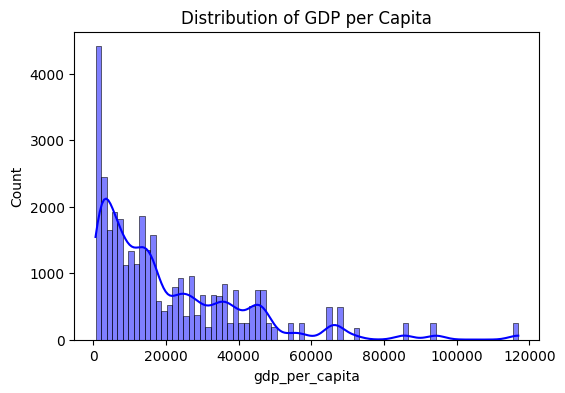

In [ ]:
# Visual 1: Target Variable Histogram
plt.figure(figsize=(6,4))
sns.histplot(df_reg['gdp_per_capita'], kde=True, color='blue')
plt.title('Distribution of GDP per Capita')
plt.show()

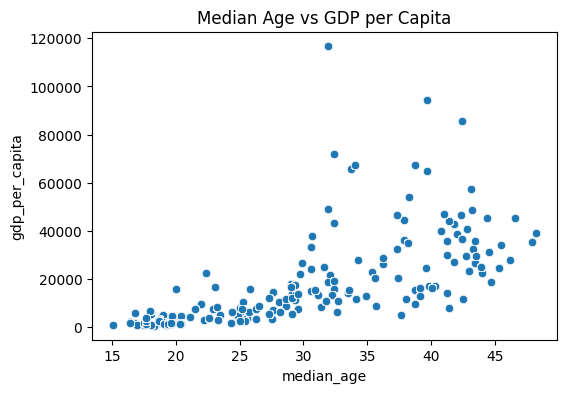

In [ ]:
# Visual 2: Scatter plot (Correlation check)
plt.figure(figsize=(6,4))
sns.scatterplot(x='median_age', y='gdp_per_capita', data=df_reg)
plt.title('Median Age vs GDP per Capita')
plt.show()

# STEP 2: NEURAL NETWORK (MLP REGRESSOR)

In [ ]:
# Prepare Features (X) and Target (y)
X = df_reg.drop('gdp_per_capita', axis=1)
y = df_reg['gdp_per_capita']

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Scale data (Essential for Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 1. Make predictions using the test data
# We use 'X_test_scaled' because the model was trained on scaled data
y_pred = mlp.predict(X_test_scaled)

# 2. Calculate the evaluation scores
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# 3. Print the results in a simple way
print("--- Neural Network (MLP) Output ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score: {r2:.4f}")

--- Neural Network (MLP) Output ---
Mean Squared Error (MSE): 172160124.14
Root Mean Squared Error (RMSE): 13120.98
R-squared Score: 0.5897


# STEP 3: CLASSICAL MODELS

In [ ]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [ ]:
# Model 2: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [ ]:
print("\n--- Classical Models Results ---")
print("Linear Regression R2:", r2_score(y_test, lr_pred))
print("Random Forest R2:", r2_score(y_test, rf_pred))


--- Classical Models Results ---
Linear Regression R2: 0.4913416956215433
Random Forest R2: 0.9999028428732655


# STEP 4: HYPERPARAMETER OPTIMIZATION

In [ ]:
# Tuning Random Forest using GridSearchCV
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

In [ ]:
# 1. Print the best settings the grid search found
# This tells you which 'n_estimators' and 'max_depth' worked best
print("--- Grid Search Results ---")
print("Best Hyperparameters:", grid_search.best_params_)

# 2. Print the average score during cross-validation
# This is the average R-squared score during the training phase
print(f"Best Cross-Validation Score (R2): {grid_search.best_score_:.4f}")

# 3. Get the best model to use for testing
best_rf_model = grid_search.best_estimator_

# 4. Predict using the best model on the test data
y_pred_best = best_rf_model.predict(X_test)

# 5. Calculate the final performance metrics
print("\n--- Final Model Performance (Test Set) ---")
print(f"Final Test R-squared: {r2_score(y_test, y_pred_best):.4f}")
print(f"Final Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f}")

--- Grid Search Results ---
Best Hyperparameters: {'max_depth': 10, 'n_estimators': 50}
Best Cross-Validation Score (R2): 0.9336

--- Final Model Performance (Test Set) ---
Final Test R-squared: 0.9336
Final Test RMSE: 5277.72


# STEP 5: FEATURE SELECTION (Filter Method)

In [ ]:
# Use SelectKBest to find top 3 features
selector = SelectKBest(score_func=f_regression, k=3)
X_train_new = selector.fit_transform(X_train, y_train)
X_test_new = selector.transform(X_test)

In [ ]:
selected_features = X.columns[selector.get_support()]
print("\nSelected Features:", list(selected_features))


Selected Features: ['total_cases_per_million', 'population_density', 'median_age']


# STEP 6: FINAL MODELS COMPARISON

In [ ]:
# Re-train Random Forest with best params and selected features
final_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
final_model.fit(X_train_new, y_train)
final_pred = final_model.predict(X_test_new)

In [ ]:
# Table Data (Printing values for your report table)
print("\n--- Final Comparison Data ---")
print(f"Final RMSE: {np.sqrt(mean_squared_error(y_test, final_pred))}")
print(f"Final R-squared: {r2_score(y_test, final_pred)}")


--- Final Comparison Data ---
Final RMSE: 4934.953642823598
Final R-squared: 0.9419602959067334
